
# TEHI-2026 — VACP-CVDP Experiment V2
## Shift-aware conformal reliability across consecutive software releases

This notebook evaluates whether conformal reliability transfers from a historical software release to the immediately following release.

### Methods compared
1. **Split CP** — ordinary source-calibrated conformal prediction.
2. **Mondrian CP** — source-calibrated class-conditional conformal prediction.
3. **VA-SWMCP (proposed)** — **Version-Aware Shift-Weighted Mondrian Conformal Prediction**, which uses *unlabeled target-release covariates* to estimate source-to-target density ratios and importance-weight the class-conditional conformal p-values.

### Important methodological corrections in V2
- Temporal shift is summarized with a **symmetric domain-separability score**, so an AUC below 0.5 is not incorrectly interpreted as “negative shift.”
- Small calibration classes use an exact finite-sample-safe conformal threshold (`q=1` when the requested order statistic lies beyond the available calibration sample).
- The inferential workflow reports both **release-pair-level** and **project-level** paired tests.
- Exact source-target feature-vector overlap is measured and a **novel-only sensitivity analysis** is repeated after removing exact overlaps.
- The proposed weighted method never uses target defect labels for fitting, calibration, or density-ratio estimation.

### Dataset provenance
The experiment uses the class-level software defect datasets introduced by:

**M. Jureczko and L. Madeyski, “Towards identifying software project clusters with regard to defect prediction,” PROMISE 2010, DOI: 10.1145/1868328.1868342.**

The CSV files are retrieved programmatically from the public `feiwww/PROMISE-backup` mirror. The paper must cite the original Jureczko–Madeyski dataset publication and state the retrieval mirror explicitly.

**Primary estimand:** empirical next-release coverage at nominal 90% coverage.  
**Primary base learner:** Random Forest.  
**Robustness learner:** Logistic Regression.  
**No GPU is required.**


In [1]:

!pip -q install pandas numpy scikit-learn scipy matplotlib


In [2]:

import math, warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr, wilcoxon, friedmanchisquare
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    matthews_corrcoef, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

RANDOM_SEEDS = [13, 37, 73, 101, 137]
ALPHA = 0.10
NOMINAL = 1 - ALPHA
EPS = 1e-6

OUTPUT = Path("tehi_vacp_cvdp_v2_outputs")
OUTPUT.mkdir(exist_ok=True)
print("Output folder:", OUTPUT.resolve())


Output folder: /content/tehi_vacp_cvdp_v2_outputs



## 1. Dataset configuration

The study uses **10 open-source Java projects, 38 releases, and 28 consecutive release transitions**. Each row is a class/module-version observation. The original `bug` field is converted to a binary target (`bug > 0`), and the identifier field `name` is excluded from predictors.

The benchmark contains 20 static object-oriented/code metrics per release in the selected files. The chronological pairing is fixed *a priori*; no target labels are used to select release pairs.


In [3]:

BASE = "https://raw.githubusercontent.com/feiwww/PROMISE-backup/master/bug-data"

PROJECTS = {
    "ant":      ["1.3","1.4","1.5","1.6","1.7"],
    "camel":    ["1.0","1.2","1.4","1.6"],
    "jedit":    ["3.2","4.0","4.1","4.2","4.3"],
    "log4j":    ["1.0","1.1","1.2"],
    "lucene":   ["2.0","2.2","2.4"],
    "poi":      ["1.5","2.0","2.5","3.0"],
    "synapse":  ["1.0","1.1","1.2"],
    "velocity": ["1.4","1.5","1.6"],
    "xalan":    ["2.4","2.5","2.6","2.7"],
    "xerces":   ["1.1","1.2","1.3","1.4.4"],
}

DATASET_REFERENCE = (
    "Jureczko, M.; Madeyski, L. (2010). Towards identifying software project "
    "clusters with regard to defect prediction. PROMISE 2010. "
    "DOI: 10.1145/1868328.1868342."
)
RETRIEVAL_MIRROR = "https://github.com/feiwww/PROMISE-backup"

def load_release(project, version):
    url = f"{BASE}/{project}/{project}-{version}.csv"
    df = pd.read_csv(url)
    df.columns = [str(c).strip().lower() for c in df.columns]
    if "bug" not in df.columns:
        raise ValueError(f"No bug column in {project}-{version}: {df.columns.tolist()}")
    y = (pd.to_numeric(df["bug"], errors="coerce").fillna(0) > 0).astype(int)
    X = df.drop(columns=[c for c in ["bug", "name"] if c in df.columns]).copy()
    for c in X.columns:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    return X, y

DATA = {}
summary = []

for project, versions in PROJECTS.items():
    for version in versions:
        X, y = load_release(project, version)
        DATA[(project, version)] = (X, y)
        summary.append({
            "project": project,
            "version": version,
            "n": len(y),
            "defective": int(y.sum()),
            "defect_rate": float(y.mean()),
            "n_features": X.shape[1],
        })

summary_df = pd.DataFrame(summary)
display(summary_df)

project_summary = (
    summary_df.groupby("project", as_index=False)
    .agg(
        releases=("version", "count"),
        module_version_observations=("n", "sum"),
        defective_observations=("defective", "sum")
    )
)
project_summary["transitions"] = project_summary["releases"] - 1
project_summary["defect_rate"] = (
    project_summary["defective_observations"] /
    project_summary["module_version_observations"]
)

display(project_summary)
print("Total releases:", len(summary_df))
print("Total module-version observations:", int(summary_df["n"].sum()))
print("Total defective observations:", int(summary_df["defective"].sum()))
print("Consecutive transitions:", int(project_summary["transitions"].sum()))
print("\nDataset reference:", DATASET_REFERENCE)
print("CSV retrieval mirror:", RETRIEVAL_MIRROR)

summary_df.to_csv(OUTPUT / "dataset_release_summary.csv", index=False)
project_summary.to_csv(OUTPUT / "dataset_project_summary.csv", index=False)


,project,version,n,defective,defect_rate,n_features
0,ant,1.3,125,20,0.160000,20
1,ant,1.4,178,40,0.224719,20
2,ant,1.5,293,32,0.109215,20
3,ant,1.6,351,92,0.262108,20
4,ant,1.7,745,166,0.222819,20
5,camel,1.0,339,13,0.038348,20
6,camel,1.2,608,216,0.355263,20
7,camel,1.4,872,145,0.166284,20
8,camel,1.6,965,188,0.194819,20
9,jedit,3.2,272,90,0.330882,20


,project,releases,module_version_observations,defective_observations,transitions,defect_rate
0,ant,5,1692,350,4,0.206856
1,camel,4,2784,562,3,0.201868
2,jedit,5,1749,303,4,0.173242
3,log4j,3,449,260,2,0.579065
4,lucene,3,782,438,2,0.560102
5,poi,4,1378,707,3,0.513062
6,synapse,3,635,162,2,0.255118
7,velocity,3,639,367,2,0.574335
8,xalan,4,3320,1806,3,0.543976
9,xerces,4,1643,654,3,0.398052


Total releases: 38
Total module-version observations: 15071
Total defective observations: 5609
Consecutive transitions: 28

Dataset reference: Jureczko, M.; Madeyski, L. (2010). Towards identifying software project clusters with regard to defect prediction. PROMISE 2010. DOI: 10.1145/1868328.1868342.
CSV retrieval mirror: https://github.com/feiwww/PROMISE-backup



## 2. Base learners and conformal methods

For each source release, 70% is used as proper training data and 30% as source calibration data. The immediately following release is the target test set and is never used with defect labels during training or calibration.

For candidate label \(y\), the nonconformity score is

\[
s(x,y)=1-\hat p_y(x).
\]

### Split CP
One source-calibration quantile is used for both labels.

### Mondrian CP
A separate source-calibration quantile is estimated for each class. This is useful because defective modules are often the minority class and marginal coverage can mask poor defective-class coverage.

### Proposed VA-SWMCP
A domain classifier distinguishes source covariates from target covariates using **no target defect labels**. Its estimated domain probability is converted to an approximate density ratio

\[
\hat w(x)=\frac{\hat p_t(x)}{\hat p_s(x)}
\]

after accounting for the source/target sampling priors. These weights are then used in class-conditional weighted conformal p-values. The approach is motivated by weighted conformal prediction under covariate shift; because the density ratio is estimated rather than known, we treat the method empirically and do **not** claim an exact formal guarantee.


In [4]:

def finite_quantile_safe(scores, alpha=0.10):
    """Finite-sample split-conformal threshold for scores in [0,1].
    If ceil((n+1)(1-alpha)) > n, q=1 includes the candidate label for all
    possible bounded nonconformity scores and avoids optimistic small-class behavior.
    """
    scores = np.asarray(scores, dtype=float)
    scores = scores[np.isfinite(scores)]
    n = len(scores)
    if n == 0:
        return 1.0

    k = int(math.ceil((n + 1) * (1 - alpha)))  # 1-indexed order statistic
    if k > n:
        return 1.0

    return float(np.sort(scores)[k - 1])


def make_model(name, seed):
    if name == "RF":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=2,
                class_weight="balanced",
                random_state=seed,
                n_jobs=-1
            ))
        ])

    if name == "LR":
        return Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=seed
            ))
        ])

    raise ValueError(name)


def build_sets_from_thresholds(probs, q_global=None, q_by_class=None):
    sets = []
    for pr in probs:
        labels = []
        for y in [0, 1]:
            q = q_by_class[y] if q_by_class is not None else q_global
            if 1 - pr[y] <= q:
                labels.append(y)
        sets.append(labels)
    return sets


def cp_metrics(prediction_sets, y):
    y = np.asarray(y, dtype=int)
    sizes = np.array([len(s) for s in prediction_sets])
    covered = np.array([int(int(yy) in s) for yy, s in zip(y, prediction_sets)])

    def cov(mask):
        return float(covered[mask].mean()) if mask.sum() > 0 else np.nan

    return {
        "coverage": float(covered.mean()),
        "coverage_clean": cov(y == 0),
        "coverage_defect": cov(y == 1),
        "avg_set_size": float(sizes.mean()),
        "singleton_rate": float((sizes == 1).mean()),
        "ambiguous_rate": float((sizes == 2).mean()),
        "empty_rate": float((sizes == 0).mean()),
    }


def point_metrics(y, p1):
    y = np.asarray(y, dtype=int)
    pred = (p1 >= 0.5).astype(int)

    ans = {
        "mcc": float(matthews_corrcoef(y, pred)),
        "f1": float(f1_score(y, pred, zero_division=0)),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall": float(recall_score(y, pred, zero_division=0)),
    }

    ans["pr_auc"] = (
        float(average_precision_score(y, p1))
        if len(np.unique(y)) > 1 else np.nan
    )
    ans["roc_auc"] = (
        float(roc_auc_score(y, p1))
        if len(np.unique(y)) > 1 else np.nan
    )
    return ans


def domain_auc_raw(Xs, Xt, seed=42):
    """Cross-validated AUC of a domain classifier (source=0, target=1)."""
    cols = sorted(set(Xs.columns) & set(Xt.columns))
    X = pd.concat([Xs[cols], Xt[cols]], ignore_index=True)
    d = np.r_[np.zeros(len(Xs), dtype=int), np.ones(len(Xt), dtype=int)]

    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("lr", LogisticRegression(max_iter=2000))
    ])

    minclass = np.bincount(d).min()
    n_splits = max(2, min(5, int(minclass)))
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return float(cross_val_score(pipe, X, d, cv=cv, scoring="roc_auc").mean())


def symmetric_domain_auc(raw_auc):
    """0.5 = indistinguishable; 1.0 = perfectly separable in either orientation."""
    return float(0.5 + abs(raw_auc - 0.5))


def exact_overlap_mask(Xs, Xt):
    cols = sorted(set(Xs.columns) & set(Xt.columns))
    A = Xs[cols].round(10).astype(str).agg("|".join, axis=1)
    B = Xt[cols].round(10).astype(str).agg("|".join, axis=1)
    source = set(A)
    return B.isin(source).to_numpy()


def fit_density_ratio_model(Xs, Xt):
    """Estimate p_target(x)/p_source(x) from unlabeled source/target covariates.

    A logistic domain classifier is fit on the pooled covariates. With sample
    prior pi_s=n_s/(n_s+n_t), pi_t=n_t/(n_s+n_t):
       p_t(x)/p_s(x) = odds(domain=target|x) * pi_s/pi_t.
    """
    cols = sorted(set(Xs.columns) & set(Xt.columns))
    Xpool = pd.concat([Xs[cols], Xt[cols]], ignore_index=True)
    domain = np.r_[np.zeros(len(Xs), dtype=int), np.ones(len(Xt), dtype=int)]

    model = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("lr", LogisticRegression(max_iter=3000, C=1.0))
    ])
    model.fit(Xpool, domain)

    prior_ratio = len(Xs) / len(Xt)

    def weights(X):
        p_t = model.predict_proba(X[cols])[:, 1]
        p_t = np.clip(p_t, EPS, 1 - EPS)
        odds = p_t / (1 - p_t)
        w = odds * prior_ratio
        return np.asarray(w, dtype=float)

    return weights


def effective_sample_size(weights):
    w = np.asarray(weights, dtype=float)
    if len(w) == 0 or np.sum(w*w) == 0:
        return np.nan
    return float((w.sum() ** 2) / np.sum(w ** 2))


def weighted_mondrian_sets(probs_test, cal_scores, ycal, wcal, wtest, alpha=0.10):
    """Non-randomized importance-weighted Mondrian conformal classifier.

    For each test point and candidate label y:
       p_y = [sum_i w_i I(S_i >= S_test(y)) + w_test] /
             [sum_i w_i + w_test],
    where the calibration sum is restricted to calibration samples of class y.

    Candidate y is included when p_y > alpha.
    """
    ycal = np.asarray(ycal, dtype=int)
    cal_scores = np.asarray(cal_scores, dtype=float)
    wcal = np.asarray(wcal, dtype=float)
    wtest = np.asarray(wtest, dtype=float)

    sets = []

    for j, pr in enumerate(probs_test):
        labels = []
        for y in [0, 1]:
            mask = (ycal == y)

            if mask.sum() == 0:
                # No class-specific evidence -> conservative inclusion.
                labels.append(y)
                continue

            s_test = 1 - pr[y]
            numerator = (
                wcal[mask][cal_scores[mask] >= s_test].sum()
                + wtest[j]
            )
            denominator = wcal[mask].sum() + wtest[j]
            p_value = numerator / denominator

            if p_value > alpha:
                labels.append(y)

        sets.append(labels)

    return sets



## 3. Chronological cross-version experiment

Each chronological transition is repeated over five random source train/calibration splits. The target release is held fixed. For the proposed method, only target **features** are supplied to the density-ratio estimator; target defect labels are used solely after prediction for evaluation.


In [8]:

rows = []

for project, versions in PROJECTS.items():
    for i in range(len(versions) - 1):
        source_version, target_version = versions[i], versions[i + 1]

        Xs, ys = DATA[(project, source_version)]
        Xt, yt = DATA[(project, target_version)]

        common = sorted(set(Xs.columns) & set(Xt.columns))
        Xs = Xs[common].copy()
        Xt = Xt[common].copy()

        raw_auc = domain_auc_raw(Xs, Xt)
        shift_auc = symmetric_domain_auc(raw_auc)

        duplicate_mask = exact_overlap_mask(Xs, Xt)

        # Density-ratio estimator is label-free with respect to the target release.
        ratio_fn = fit_density_ratio_model(Xs, Xt)
        w_target = ratio_fn(Xt)

        for model_name in ["RF", "LR"]:
            for seed in RANDOM_SEEDS:

                Xtr, Xcal, ytr, ycal = train_test_split(
                    Xs, ys,
                    test_size=0.30,
                    stratify=ys,
                    random_state=seed
                )

                model = make_model(model_name, seed)
                model.fit(Xtr, ytr)

                pcal = model.predict_proba(Xcal)
                ptest = model.predict_proba(Xt)

                ycal_arr = np.asarray(ycal, dtype=int)

                # Calibration nonconformity score assigned to observed class.
                scores = 1 - pcal[np.arange(len(ycal_arr)), ycal_arr]

                # ---------- Baseline 1: ordinary Split CP ----------
                q_global = finite_quantile_safe(scores, ALPHA)
                std_sets = build_sets_from_thresholds(
                    ptest, q_global=q_global
                )

                # ---------- Baseline 2: Mondrian CP ----------
                q_by_class = {}
                cal_counts = {}
                for cls in [0, 1]:
                    cls_scores = scores[ycal_arr == cls]
                    cal_counts[cls] = int(len(cls_scores))
                    q_by_class[cls] = finite_quantile_safe(cls_scores, ALPHA)

                mon_sets = build_sets_from_thresholds(
                    ptest, q_by_class=q_by_class
                )

                # ---------- Proposed: VA-SWMCP ----------
                w_cal = ratio_fn(Xcal)
                swm_sets = weighted_mondrian_sets(
                    ptest, scores, ycal_arr,
                    wcal=w_cal,
                    wtest=w_target,
                    alpha=ALPHA
                )

                pm = point_metrics(yt, ptest[:, 1])
                std = cp_metrics(std_sets, yt)
                mon = cp_metrics(mon_sets, yt)
                swm = cp_metrics(swm_sets, yt)

                base = {
                    "project": project,
                    "source": source_version,
                    "target": target_version,
                    "pair": f"{project}:{source_version}->{target_version}",
                    "model": model_name,
                    "seed": seed,
                    "n_source": len(ys),
                    "n_target": len(yt),
                    "source_defect_rate": float(ys.mean()),
                    "target_defect_rate": float(yt.mean()),
                    "domain_auc_raw": raw_auc,
                    "shift_auc_symmetric": shift_auc,
                    "exact_overlap_rate": float(duplicate_mask.mean()),
                    "cal_n_clean": cal_counts[0],
                    "cal_n_defect": cal_counts[1],
                    "weight_ess": effective_sample_size(w_cal),
                    "weight_mean": float(np.mean(w_cal)),
                    "weight_max": float(np.max(w_cal)),
                }

                result = {
                    **base,
                    **{f"point_{k}": v for k, v in pm.items()},
                    **{f"std_{k}": v for k, v in std.items()},
                    **{f"mon_{k}": v for k, v in mon.items()},
                    **{f"swm_{k}": v for k, v in swm.items()},
                }

                # ---------- Novel-only sensitivity ----------
                keep = ~duplicate_mask
                if keep.sum() >= 10 and len(np.unique(np.asarray(yt)[keep])) > 1:
                    yt_novel = np.asarray(yt)[keep]
                    pm2 = point_metrics(yt_novel, ptest[keep, 1])
                    std2 = cp_metrics(
                        [std_sets[j] for j in np.where(keep)[0]], yt_novel
                    )
                    mon2 = cp_metrics(
                        [mon_sets[j] for j in np.where(keep)[0]], yt_novel
                    )
                    swm2 = cp_metrics(
                        [swm_sets[j] for j in np.where(keep)[0]], yt_novel
                    )

                    result.update({f"novel_point_{k}": v for k, v in pm2.items()})
                    result.update({f"novel_std_{k}": v for k, v in std2.items()})
                    result.update({f"novel_mon_{k}": v for k, v in mon2.items()})
                    result.update({f"novel_swm_{k}": v for k, v in swm2.items()})

                rows.append(result)

raw = pd.DataFrame(rows)
raw.to_csv(OUTPUT / "all_seed_results_v2.csv", index=False)

print("Seed-level rows:", len(raw))
print("Expected:", 28 * 2 * len(RANDOM_SEEDS))
display(raw.head())


Seed-level rows: 280
Expected: 280


,project,source,target,pair,model,seed,n_source,n_target,source_defect_rate,target_defect_rate,...,novel_mon_singleton_rate,novel_mon_ambiguous_rate,novel_mon_empty_rate,novel_swm_coverage,novel_swm_coverage_clean,novel_swm_coverage_defect,novel_swm_avg_set_size,novel_swm_singleton_rate,novel_swm_ambiguous_rate,novel_swm_empty_rate
0,ant,1.3,1.4,ant:1.3->1.4,RF,13,125,178,0.16,0.224719,...,0.227586,0.772414,0.0,0.868966,0.819048,1.000,1.779310,0.220690,0.779310,0.0
1,ant,1.3,1.4,ant:1.3->1.4,RF,37,125,178,0.16,0.224719,...,0.227586,0.772414,0.0,0.827586,0.761905,1.000,1.731034,0.268966,0.731034,0.0
2,ant,1.3,1.4,ant:1.3->1.4,RF,73,125,178,0.16,0.224719,...,0.262069,0.737931,0.0,0.806897,0.742857,0.975,1.696552,0.303448,0.696552,0.0
3,ant,1.3,1.4,ant:1.3->1.4,RF,101,125,178,0.16,0.224719,...,0.241379,0.758621,0.0,0.841379,0.790476,0.975,1.744828,0.255172,0.744828,0.0
4,ant,1.3,1.4,ant:1.3->1.4,RF,137,125,178,0.16,0.224719,...,0.144828,0.855172,0.0,0.868966,0.828571,0.975,1.800000,0.200000,0.800000,0.0



## 4. Pair-level aggregation and robust statistical tests

The primary unit of analysis is the **chronological release transition**. Results are averaged across the five source splits before inferential comparisons. Because several transitions belong to the same project, a secondary **project-level** analysis averages transition-level results within each project before paired tests.


In [9]:

num_cols = raw.select_dtypes(include=np.number).columns.tolist()

pair = (
    raw.groupby(
        ["project", "source", "target", "pair", "model"],
        as_index=False
    )[num_cols]
    .mean()
)

pair.to_csv(OUTPUT / "pair_level_results_v2.csv", index=False)

metrics = [
    "point_mcc", "point_f1", "point_pr_auc", "point_roc_auc",
    "std_coverage", "std_coverage_defect", "std_avg_set_size",
    "mon_coverage", "mon_coverage_defect", "mon_avg_set_size",
    "swm_coverage", "swm_coverage_defect", "swm_avg_set_size",
    "shift_auc_symmetric", "exact_overlap_rate", "weight_ess"
]

agg = pair.groupby("model")[metrics].agg(["mean", "median", "std"])
display(agg.round(3))
agg.to_csv(OUTPUT / "aggregate_summary_v2.csv")

# ---------------- Primary RF analysis ----------------
rf = pair[pair["model"] == "RF"].copy()

for method in ["std", "mon", "swm"]:
    rf[f"{method}_cov_abs_error"] = (rf[f"{method}_coverage"] - NOMINAL).abs()
    rf[f"{method}_def_abs_error"] = (rf[f"{method}_coverage_defect"] - NOMINAL).abs()
    rf[f"{method}_cov_shortfall"] = NOMINAL - rf[f"{method}_coverage"]
    rf[f"{method}_def_shortfall"] = NOMINAL - rf[f"{method}_coverage_defect"]

def safe_wilcoxon(a, b, alternative="two-sided"):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    mask = np.isfinite(a) & np.isfinite(b)
    a, b = a[mask], b[mask]
    if len(a) == 0 or np.allclose(a, b):
        return {"statistic": np.nan, "p": np.nan, "n": int(len(a))}
    res = wilcoxon(a, b, alternative=alternative, zero_method="wilcox")
    return {"statistic": float(res.statistic), "p": float(res.pvalue), "n": int(len(a))}

# Error reductions: lower absolute error is better.
pair_swm_vs_std_def = safe_wilcoxon(
    rf["std_def_abs_error"], rf["swm_def_abs_error"], alternative="greater"
)
pair_swm_vs_mon_def = safe_wilcoxon(
    rf["mon_def_abs_error"], rf["swm_def_abs_error"], alternative="greater"
)
pair_swm_vs_std_marg = safe_wilcoxon(
    rf["std_cov_abs_error"], rf["swm_cov_abs_error"], alternative="greater"
)

# Omnibus comparison across 3 methods.
fried_def = friedmanchisquare(
    rf["std_def_abs_error"],
    rf["mon_def_abs_error"],
    rf["swm_def_abs_error"]
)
fried_marg = friedmanchisquare(
    rf["std_cov_abs_error"],
    rf["mon_cov_abs_error"],
    rf["swm_cov_abs_error"]
)

# Secondary project-level analysis.
project_rf = (
    rf.groupby("project", as_index=False)
      .mean(numeric_only=True)
)

project_swm_vs_std_def = safe_wilcoxon(
    project_rf["std_def_abs_error"],
    project_rf["swm_def_abs_error"],
    alternative="greater"
)
project_swm_vs_mon_def = safe_wilcoxon(
    project_rf["mon_def_abs_error"],
    project_rf["swm_def_abs_error"],
    alternative="greater"
)

# Shift associations.
rho_std, p_std = spearmanr(
    rf["shift_auc_symmetric"],
    rf["std_cov_shortfall"],
    nan_policy="omit"
)
rho_swm, p_swm = spearmanr(
    rf["shift_auc_symmetric"],
    rf["swm_cov_shortfall"],
    nan_policy="omit"
)

# Does proposed weighting help more when shift is stronger?
rf["def_error_improvement_swm_over_std"] = (
    rf["std_def_abs_error"] - rf["swm_def_abs_error"]
)
rho_imp, p_imp = spearmanr(
    rf["shift_auc_symmetric"],
    rf["def_error_improvement_swm_over_std"],
    nan_policy="omit"
)

# Novel-only summary if available.
novel_cols = [
    "novel_std_coverage", "novel_std_coverage_defect",
    "novel_mon_coverage", "novel_mon_coverage_defect",
    "novel_swm_coverage", "novel_swm_coverage_defect"
]
novel_summary = {}
for c in novel_cols:
    if c in rf.columns:
        novel_summary[c] = float(rf[c].mean(skipna=True))

stats = {
    "n_release_pairs": int(len(rf)),
    "n_projects": int(rf["project"].nunique()),
    "RF_mean_MCC": float(rf["point_mcc"].mean()),
    "RF_mean_PR_AUC": float(rf["point_pr_auc"].mean()),

    "std_mean_coverage": float(rf["std_coverage"].mean()),
    "std_mean_defect_coverage": float(rf["std_coverage_defect"].mean()),
    "std_mean_set_size": float(rf["std_avg_set_size"].mean()),

    "mon_mean_coverage": float(rf["mon_coverage"].mean()),
    "mon_mean_defect_coverage": float(rf["mon_coverage_defect"].mean()),
    "mon_mean_set_size": float(rf["mon_avg_set_size"].mean()),

    "swm_mean_coverage": float(rf["swm_coverage"].mean()),
    "swm_mean_defect_coverage": float(rf["swm_coverage_defect"].mean()),
    "swm_mean_set_size": float(rf["swm_avg_set_size"].mean()),

    "pair_wilcoxon_std_vs_swm_defect": pair_swm_vs_std_def,
    "pair_wilcoxon_mon_vs_swm_defect": pair_swm_vs_mon_def,
    "pair_wilcoxon_std_vs_swm_marginal": pair_swm_vs_std_marg,

    "project_wilcoxon_std_vs_swm_defect": project_swm_vs_std_def,
    "project_wilcoxon_mon_vs_swm_defect": project_swm_vs_mon_def,

    "friedman_defect_error_stat": float(fried_def.statistic),
    "friedman_defect_error_p": float(fried_def.pvalue),
    "friedman_marginal_error_stat": float(fried_marg.statistic),
    "friedman_marginal_error_p": float(fried_marg.pvalue),

    "mean_raw_domain_auc": float(rf["domain_auc_raw"].mean()),
    "mean_symmetric_shift_auc": float(rf["shift_auc_symmetric"].mean()),
    "spearman_shift_std_shortfall_rho": float(rho_std),
    "spearman_shift_std_shortfall_p": float(p_std),
    "spearman_shift_swm_shortfall_rho": float(rho_swm),
    "spearman_shift_swm_shortfall_p": float(p_swm),
    "spearman_shift_vs_swm_def_error_improvement_rho": float(rho_imp),
    "spearman_shift_vs_swm_def_error_improvement_p": float(p_imp),

    "mean_exact_overlap_rate": float(rf["exact_overlap_rate"].mean()),
    "mean_weight_ess": float(rf["weight_ess"].mean()),
    **novel_summary
}

print(json.dumps(stats, indent=2))
with open(OUTPUT / "key_statistics_v2.json", "w") as f:
    json.dump(stats, f, indent=2)

project_rf.to_csv(OUTPUT / "project_level_results_v2.csv", index=False)


point_mcc               point_f1               point_pr_auc         \
           mean median    std     mean median    std         mean median   
model                                                                      
LR        0.189  0.180  0.155    0.461  0.501  0.172        0.533  0.558   
RF        0.221  0.224  0.154    0.414  0.427  0.223        0.541  0.554   

             point_roc_auc  ... swm_avg_set_size shift_auc_symmetric         \
         std          mean  ...              std                mean median   
model                       ...                                               
LR     0.233         0.646  ...            0.125               0.566  0.546   
RF     0.238         0.681  ...            0.167               0.566  0.546   

             exact_overlap_rate               weight_ess                  
         std               mean median    std       mean  median     std  
model                                                                     
LR     0.057              0.282  0.231  0.177      96.54  82.716  65.823  
RF     0.057              0.282  0.231  0.177      96.54  82.716  65.823  

[2 rows x 48 columns]

{
  "n_release_pairs": 28,
  "n_projects": 10,
  "RF_mean_MCC": 0.22101357511155034,
  "RF_mean_PR_AUC": 0.5408108476971627,
  "std_mean_coverage": 0.7563709551948875,
  "std_mean_defect_coverage": 0.5778347176993393,
  "std_mean_set_size": 1.2252180234935415,
  "mon_mean_coverage": 0.8236798467934594,
  "mon_mean_defect_coverage": 0.8379436614145647,
  "mon_mean_set_size": 1.5030047197458296,
  "swm_mean_coverage": 0.8407501722004108,
  "swm_mean_defect_coverage": 0.8439468715380712,
  "swm_mean_set_size": 1.5301004017888646,
  "pair_wilcoxon_std_vs_swm_defect": {
    "statistic": 385.0,
    "p": 1.6652047634124756e-06,
    "n": 28
  },
  "pair_wilcoxon_mon_vs_swm_defect": {
    "statistic": 185.0,
    "p": 0.27245479389612526,
    "n": 28
  },
  "pair_wilcoxon_std_vs_swm_marginal": {
    "statistic": 363.0,
    "p": 4.659593105316162e-05,
    "n": 28
  },
  "project_wilcoxon_std_vs_swm_defect": {
    "statistic": 55.0,
    "p": 0.0009765625,
    "n": 10
  },
  "project_wilcoxon_mon_v


## 5. Figures


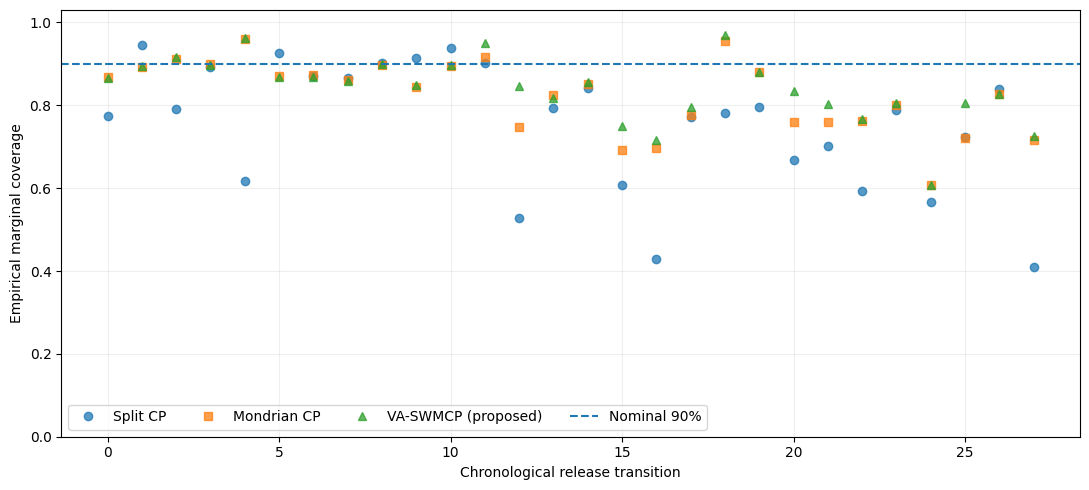

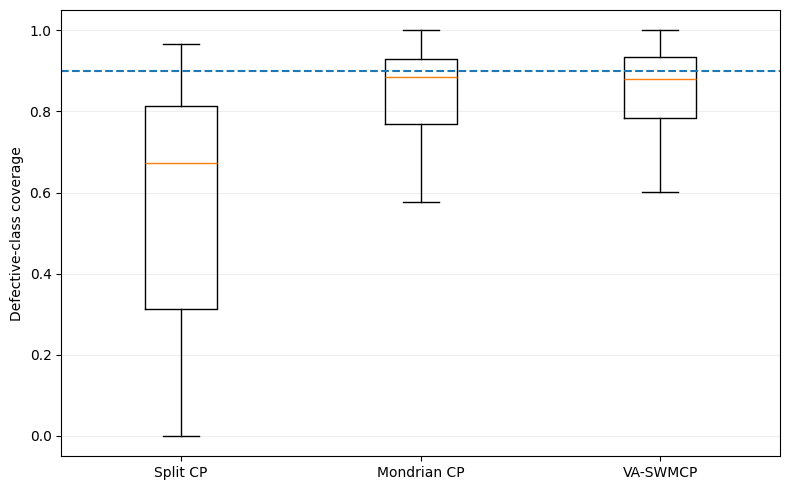

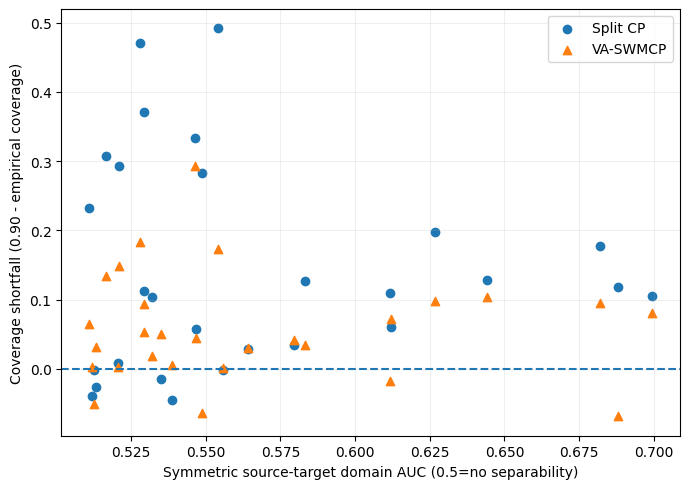

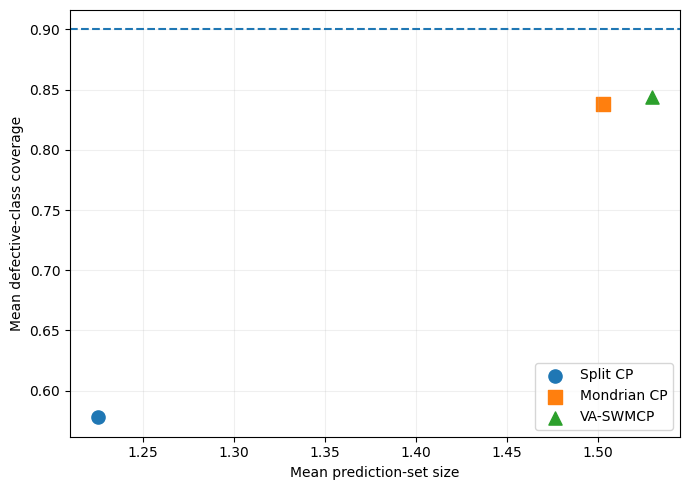

In [10]:

# Figure 1 — Marginal coverage across release transitions
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(rf))

ax.plot(x, rf["std_coverage"], "o", label="Split CP", alpha=0.75)
ax.plot(x, rf["mon_coverage"], "s", label="Mondrian CP", alpha=0.75)
ax.plot(x, rf["swm_coverage"], "^", label="VA-SWMCP (proposed)", alpha=0.75)
ax.axhline(NOMINAL, linestyle="--", label="Nominal 90%")

ax.set_ylabel("Empirical marginal coverage")
ax.set_xlabel("Chronological release transition")
ax.set_ylim(0, 1.03)
ax.legend(ncol=4)
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUTPUT / "fig1_marginal_coverage.png", dpi=220, bbox_inches="tight")
plt.show()

# Figure 2 — Defective-class coverage
fig, ax = plt.subplots(figsize=(8, 5))
vals = [
    rf["std_coverage_defect"].dropna(),
    rf["mon_coverage_defect"].dropna(),
    rf["swm_coverage_defect"].dropna()
]
ax.boxplot(vals, labels=["Split CP", "Mondrian CP", "VA-SWMCP"])
ax.axhline(NOMINAL, linestyle="--")
ax.set_ylabel("Defective-class coverage")
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(OUTPUT / "fig2_defective_class_coverage.png", dpi=220, bbox_inches="tight")
plt.show()

# Figure 3 — Symmetric temporal shift vs coverage shortfall
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(rf["shift_auc_symmetric"], rf["std_cov_shortfall"], label="Split CP")
ax.scatter(rf["shift_auc_symmetric"], rf["swm_cov_shortfall"], marker="^", label="VA-SWMCP")
ax.axhline(0, linestyle="--")
ax.set_xlabel("Symmetric source-target domain AUC (0.5=no separability)")
ax.set_ylabel("Coverage shortfall (0.90 - empirical coverage)")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUTPUT / "fig3_shift_vs_coverage_shortfall.png", dpi=220, bbox_inches="tight")
plt.show()

# Figure 4 — Reliability-efficiency trade-off
fig, ax = plt.subplots(figsize=(7, 5))
for method, label, marker in [
    ("std", "Split CP", "o"),
    ("mon", "Mondrian CP", "s"),
    ("swm", "VA-SWMCP", "^")
]:
    ax.scatter(
        rf[f"{method}_avg_set_size"].mean(),
        rf[f"{method}_coverage_defect"].mean(),
        marker=marker,
        s=90,
        label=label
    )

ax.axhline(NOMINAL, linestyle="--")
ax.set_xlabel("Mean prediction-set size")
ax.set_ylabel("Mean defective-class coverage")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(OUTPUT / "fig4_reliability_efficiency.png", dpi=220, bbox_inches="tight")
plt.show()



## 6. Automatically generated manuscript-ready result text

Use this text only after confirming that all 28 Random-Forest release pairs completed and that the output tables contain no unexpected missing values.


In [11]:

s = stats

def fmt_p(x):
    if x is None or not np.isfinite(x):
        return "NA"
    return f"{x:.3g}"

text = f"""
RESULTS INSERT — V2 (verify before submission)

The analysis covered {s['n_release_pairs']} consecutive release transitions from
{s['n_projects']} open-source Java projects. The Random Forest achieved a mean MCC
of {s['RF_mean_MCC']:.3f} and mean PR-AUC of {s['RF_mean_PR_AUC']:.3f} on the
future releases.

At a nominal 90% coverage level, ordinary Split CP obtained mean marginal coverage
of {s['std_mean_coverage']:.3f} and defective-class coverage of
{s['std_mean_defect_coverage']:.3f}, with mean prediction-set size
{s['std_mean_set_size']:.3f}. Mondrian CP obtained mean marginal coverage of
{s['mon_mean_coverage']:.3f} and defective-class coverage of
{s['mon_mean_defect_coverage']:.3f}, with mean set size
{s['mon_mean_set_size']:.3f}.

The proposed VA-SWMCP obtained mean marginal coverage of
{s['swm_mean_coverage']:.3f} and defective-class coverage of
{s['swm_mean_defect_coverage']:.3f}, with mean set size
{s['swm_mean_set_size']:.3f}. At the release-pair level, the one-sided Wilcoxon
comparison of defective-class absolute coverage error between Split CP and VA-SWMCP
gave p={fmt_p(s['pair_wilcoxon_std_vs_swm_defect']['p'])}; the comparison between
Mondrian CP and VA-SWMCP gave p={fmt_p(s['pair_wilcoxon_mon_vs_swm_defect']['p'])}.
The project-level counterparts gave p={fmt_p(s['project_wilcoxon_std_vs_swm_defect']['p'])}
and p={fmt_p(s['project_wilcoxon_mon_vs_swm_defect']['p'])}, respectively.

Source-target temporal separability averaged symmetric domain AUC
{s['mean_symmetric_shift_auc']:.3f}. Its Spearman association with ordinary Split-CP
coverage shortfall was rho={s['spearman_shift_std_shortfall_rho']:.3f}
(p={fmt_p(s['spearman_shift_std_shortfall_p'])}); the corresponding association for
VA-SWMCP was rho={s['spearman_shift_swm_shortfall_rho']:.3f}
(p={fmt_p(s['spearman_shift_swm_shortfall_p'])}).

Exact source-target feature-vector overlap averaged
{100*s['mean_exact_overlap_rate']:.1f}% of target instances. The novel-only
sensitivity estimates are exported in pair_level_results_v2.csv and must be reported
if they materially change the primary conclusion.
"""

print(text)
with open(OUTPUT / "ready_to_paste_results_v2.txt", "w") as f:
    f.write(text)



RESULTS INSERT — V2 (verify before submission)

The analysis covered 28 consecutive release transitions from
10 open-source Java projects. The Random Forest achieved a mean MCC
of 0.221 and mean PR-AUC of 0.541 on the
future releases.

At a nominal 90% coverage level, ordinary Split CP obtained mean marginal coverage
of 0.756 and defective-class coverage of
0.578, with mean prediction-set size
1.225. Mondrian CP obtained mean marginal coverage of
0.824 and defective-class coverage of
0.838, with mean set size
1.503.

The proposed VA-SWMCP obtained mean marginal coverage of
0.841 and defective-class coverage of
0.844, with mean set size
1.530. At the release-pair level, the one-sided Wilcoxon
comparison of defective-class absolute coverage error between Split CP and VA-SWMCP
gave p=1.67e-06; the comparison between
Mondrian CP and VA-SWMCP gave p=0.272.
The project-level counterparts gave p=0.000977
and p=0.312, respectively.

Source-target temporal separability averaged symmetric domai


## 7. Interpretation guardrails

- **Do not** claim that ordinary conformal coverage is guaranteed after transfer to a later software release; standard finite-sample validity relies on exchangeability.
- **Do not** call VA-SWMCP a new conformal theorem or claim exact target coverage. It is a **software-engineering adaptation of established importance-weighted conformal principles using estimated density ratios**.
- Report the **reliability-efficiency trade-off**: improved coverage can come with larger or more ambiguous prediction sets.
- Treat the defective class separately; marginal 90% coverage can conceal poor coverage of defect-prone modules.
- Report both pair-level and project-level tests because multiple transitions come from the same project.
- If exact-overlap removal changes the conclusion, make the novel-only result central to the discussion.
- Inspect `cal_n_defect` and `weight_ess`; extremely small calibration classes or low effective sample sizes must be acknowledged.
- Keep the novelty claim narrow: **a targeted cross-version software-defect study of conformal reliability transfer, with a shift-weighted class-conditional reliability layer and overlap-controlled chronological validation.**
